# Лабораторная работа №1. Кластеризация
## Вариант 3 — `load_breast_cancer`
**Базовые признаки:** `mean radius`, `mean texture`  
**Дополнительный признак:** `mean perimeter`

## 1. Загрузка данных и описание признаков

Используем датасет `load_breast_cancer` из scikit-learn.  
Он содержит 569 наблюдений (212 — malignant, 357 — benign) и 30 числовых признаков,
вычисленных из цифровых изображений тонкоигольных биопсий (FNA) опухолей молочной железы.

**Наши признаки (вариант 3):**

| Признак | Описание |
|---------|----------|
| `mean radius` | Среднее расстояние от центра клеточного ядра до его границы |
| `mean texture` | Стандартное отклонение значений серого на изображении ядра |
| `mean perimeter` | Средний периметр ядра (дополнительный признак, п. 6) |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Загрузка данных
data = load_breast_cancer()
df_full = pd.DataFrame(data.data, columns = data.feature_names)
y_true = data.target  # 0 = malignant, 1 = benign

# Базовые признаки (вариант 3): radius, texture
X_base = df_full[['mean radius', 'mean texture']].copy()
print("Размер выборки:", X_base.shape)
print()
X_base.describe().round(2)

Размер выборки: (569, 2)



,mean radius,mean texture
count,569.00,569.00
mean,14.13,19.29
std,3.52,4.30
min,6.98,9.71
25%,11.70,16.17
50%,13.37,18.84
75%,15.78,21.80
max,28.11,39.28


## 2. Диаграмма рассеивания (2 базовых признака) → визуальная оценка K₁

Строим scatter-plot по `mean radius` и `mean texture`. По визуальному расположению точек
предполагаем оптимальное число кластеров **K₁**.

> **Ожидание:** на графике видны **2 «облака»** точек (что соответствует двум классам —
> malignant/benign), поэтому визуально предполагаем **K₁ = 2**.

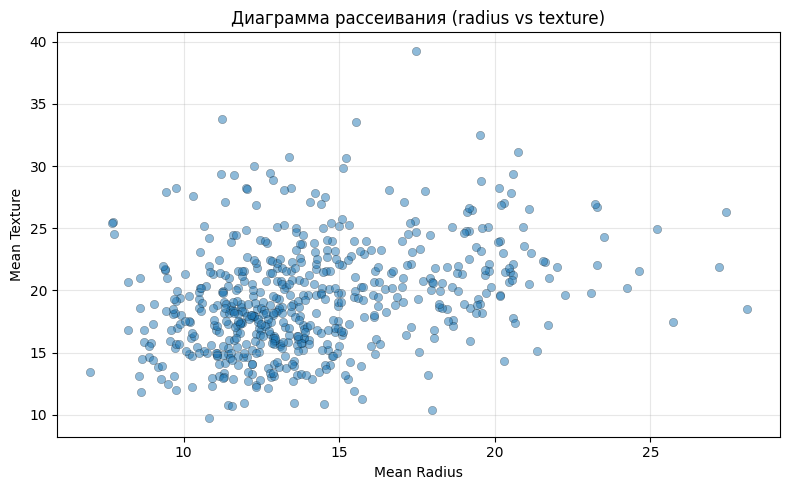

Визуальная оценка оптимального числа кластеров: K₁ = 2


In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_base['mean radius'], X_base['mean texture'],
            alpha=0.5, edgecolors='k', linewidth = 0.3)
plt.xlabel('Mean Radius')
plt.ylabel('Mean Texture')
plt.title('Диаграмма рассеивания (radius vs texture)')
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

K1 = 2
print(f"Визуальная оценка оптимального числа кластеров: K₁ = {K1}")

## 3. Метод «локтя» (Elbow method) → K₂

Метод локтя оценивает **инерцию** (WCSS — Within-Cluster Sum of Squares) для K = 1 … 10.
«Локоть» — точка, после которой снижение инерции замедляется.

> По заданию желательно, чтобы K₂ ≠ K₁. На графике «перелом» часто наблюдается
> при K = 3 — это и будет наша оценка **K₂ = 3**.

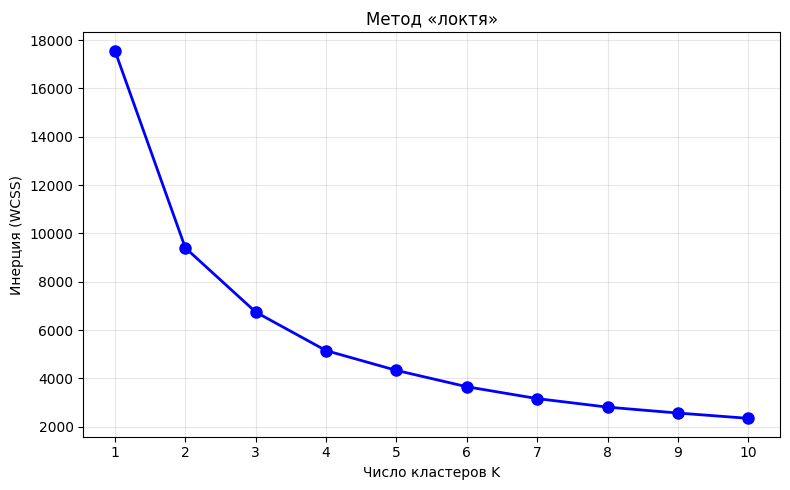

По методу локтя оптимальное число кластеров: K₂ = 3


In [ ]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    km.fit(X_base)
    inertias.append(km.inertia_)

plt.figure(figsize = (8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth = 2, markersize = 8)
plt.xlabel('Число кластеров K')
plt.ylabel('Инерция (WCSS)')
plt.title('Метод «локтя»')
plt.xticks(K_range)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

K2 = 3
print(f"По методу локтя оптимальное число кластеров: K₂ = {K2}")

## 4. Кластеризация K-means для K₁ и K₂ + силуэтный коэффициент

**Силуэтный коэффициент** (Silhouette Score) — мера качества кластеризации от −1 до +1:
- Близко к +1 → точки хорошо сгруппированы
- Близко к 0 → точки на границе кластеров  
- Отрицательные → точки в «чужом» кластере

Сравниваем разбиения для K₁ = 2 и K₂ = 3, выбираем лучшее.

In [4]:
# K-means для K1 = 2
km_k1 = KMeans(n_clusters = K1, n_init = 10, random_state = 42)
labels_k1 = km_k1.fit_predict(X_base)
sil_k1 = silhouette_score(X_base, labels_k1)

# K-means для K2 = 3
km_k2 = KMeans(n_clusters = K2, n_init = 10, random_state = 42)
labels_k2 = km_k2.fit_predict(X_base)
sil_k2 = silhouette_score(X_base, labels_k2)

print(f"K₁ = {K1}: Силуэтный коэффициент = {sil_k1:.4f}")
print(f"K₂ = {K2}: Силуэтный коэффициент = {sil_k2:.4f}")
print()

if sil_k1 > sil_k2:
    print(f"✔ Лучшее разбиение: K = {K1} (больший силуэтный коэффициент)")
    best_K_base = K1
else:
    print(f"✔ Лучшее разбиение: K = {K2} (больший силуэтный коэффициент)")
    best_K_base = K2

K₁ = 2: Силуэтный коэффициент = 0.4285
K₂ = 3: Силуэтный коэффициент = 0.4219

✔ Лучшее разбиение: K = 2 (больший силуэтный коэффициент)


## 5. Диаграмма рассеивания с кластерами и центроидами

Строим scatter-plot для обоих разбиений: точки раскрашены по кластерам, центроиды отмечены красными крестами.

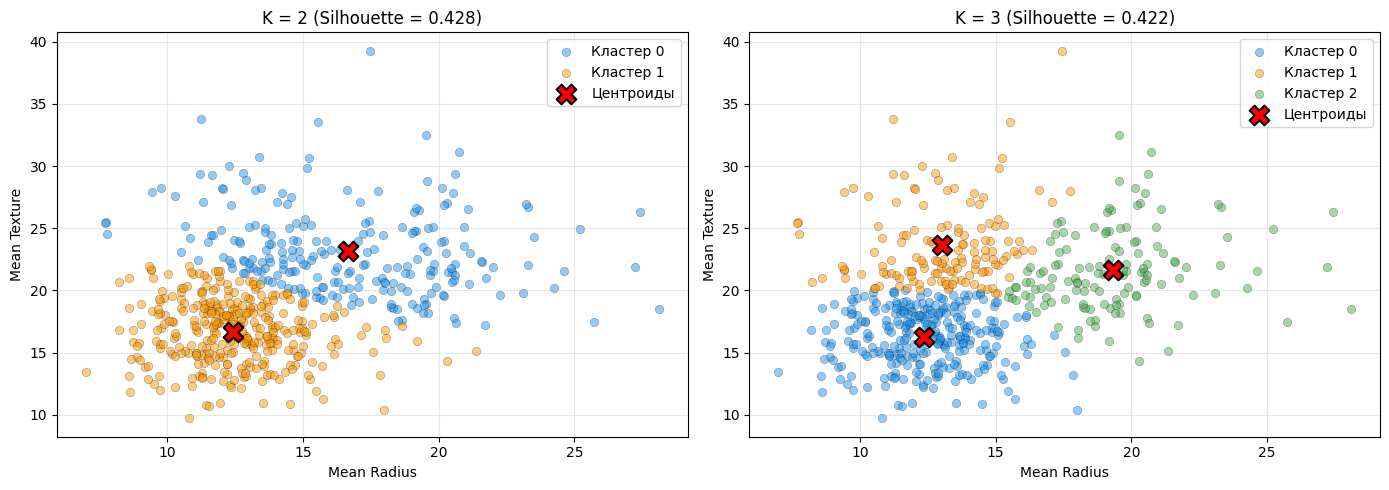

In [ ]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50', '#E91E63']

for ax, km, labels, k_val in [
    (axes[0], km_k1, labels_k1, K1),
    (axes[1], km_k2, labels_k2, K2)
]:
    for c in range(k_val):
        mask = labels == c
        ax.scatter(X_base.iloc[mask, 0], X_base.iloc[mask, 1],
                   c=colors[c], label=f'Кластер {c}', alpha = 0.5,
                   edgecolors = 'k', linewidth = 0.3)
    # Центроиды
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
               c='red', marker = 'X', s = 200, edgecolors='black',
               linewidth = 1.5, label='Центроиды', zorder = 5)
    sil = silhouette_score(X_base, labels)
    ax.set_title(f'K = {k_val} (Silhouette = {sil:.3f})')
    ax.set_xlabel('Mean Radius')
    ax.set_ylabel('Mean Texture')
    ax.legend()
    ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

## 6. Добавление дополнительного признака + разделение 80/20

Добавляем `mean perimeter` (вариант 3). Разделяем выборку на обучающую (80%) и прогнозную (20%).

In [ ]:
# Три признака
X_full = df_full[['mean radius', 'mean texture', 'mean perimeter']].copy()
print("Размер полной выборки:", X_full.shape)
print()

# Разделение 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_true, test_size = 0.2, random_state = 42
)
print(f"Обучающая выборка: {X_train.shape[0]} наблюдений")
print(f"Прогнозная выборка: {X_test.shape[0]} наблюдений")

Размер полной выборки: (569, 3)

Обучающая выборка: 455 наблюдений
Прогнозная выборка: 114 наблюдений


## 7. Метод «локтя» с тремя признаками

Повторяем метод локтя, но уже по 3 признакам (обучающая выборка). Смотрим, изменилось ли оптимальное K.

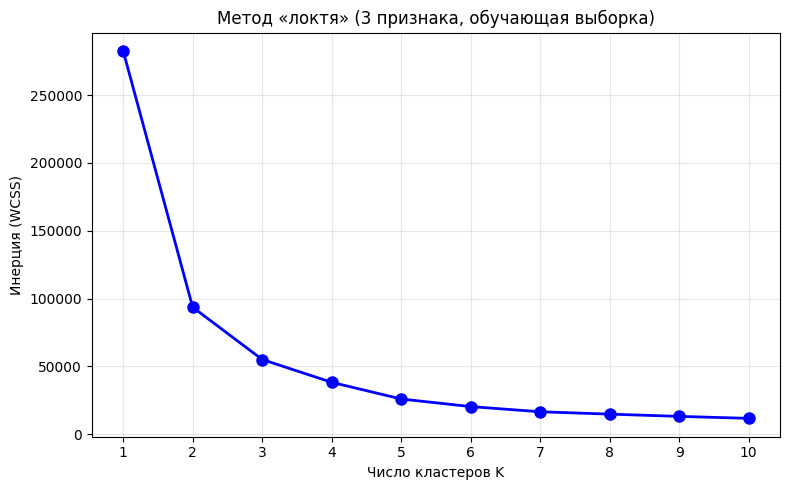

K = 2: Silhouette = 0.6213
K = 3: Silhouette = 0.4796

Оптимальное K с тремя признаками: 2
Добавление perimeter (сильно коррелирует с radius) усиливает
разделение на 2 кластера, локоть по-прежнему в районе K=2.


In [7]:
inertias_3d = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    km.fit(X_train)
    inertias_3d.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias_3d, 'bo-', linewidth = 2, markersize = 8)
plt.xlabel('Число кластеров K')
plt.ylabel('Инерция (WCSS)')
plt.title('Метод «локтя» (3 признака, обучающая выборка)')
plt.xticks(K_range)
plt.grid(True, alpha = 0.3)
plt.tight_layout()
plt.show()

# Силуэт для K=2 и K=3 на 3 признаках
for k in [2, 3]:
    km_temp = KMeans(n_clusters = k, n_init = 10, random_state = 42)
    lbl_temp = km_temp.fit_predict(X_train)
    sil_temp = silhouette_score(X_train, lbl_temp)
    print(f"K = {k}: Silhouette = {sil_temp:.4f}")

K_best_3d = 2
print(f"\nОптимальное K с тремя признаками: {K_best_3d}")
print("Добавление perimeter (сильно коррелирует с radius) усиливает")
print("разделение на 2 кластера, локоть по-прежнему в районе K=2.")

## 8. Кластеризация обучающей выборки + анализ распределений

Обучаем K-means на обучающей выборке с оптимальным K. Визуально анализируем
статистическое распределение признаков в каждом кластере (boxplot).

Размеры кластеров на обучающей выборке:
  Кластер 0: 338 наблюдений
  Кластер 1: 117 наблюдений



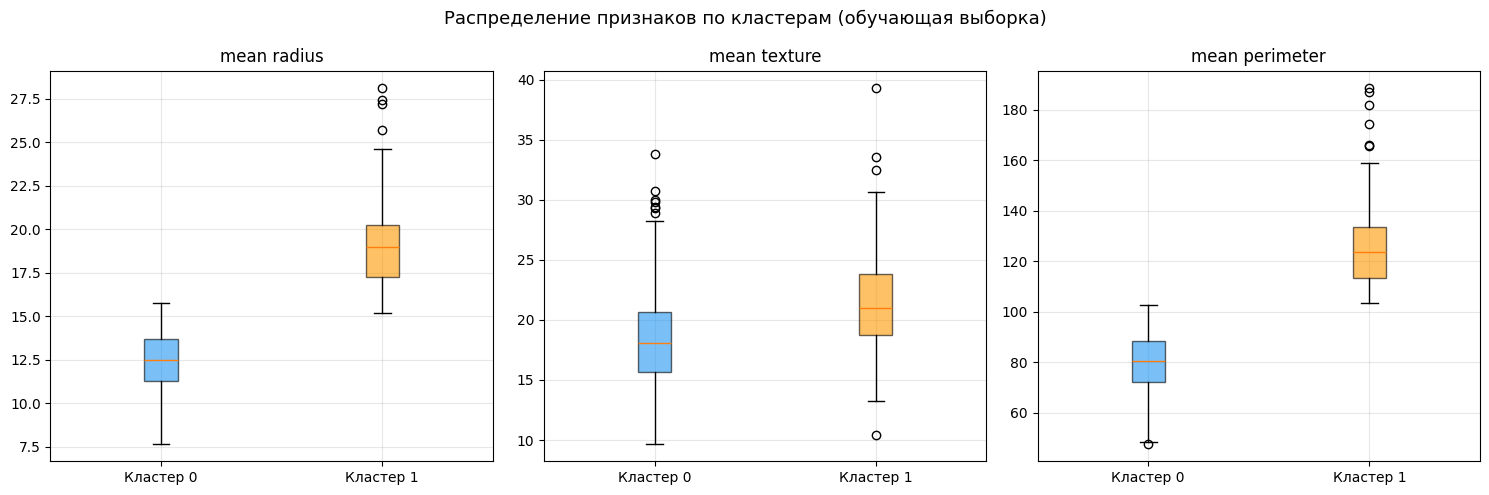


Статистика по кластерам:
         mean radius  mean texture  mean perimeter
cluster                                           
0              12.40         18.40           80.04
1              19.08         21.45          126.08


In [8]:
km_final = KMeans(n_clusters = K_best_3d, n_init = 10, random_state = 42)
train_labels = km_final.fit_predict(X_train)

print("Размеры кластеров на обучающей выборке:")
for c in range(K_best_3d):
    print(f"  Кластер {c}: {np.sum(train_labels == c)} наблюдений")
print()

# Boxplot-анализ распределений по кластерам
fig, axes = plt.subplots(1, 3, figsize = (15, 5))
features = ['mean radius', 'mean texture', 'mean perimeter']

for i, feat in enumerate(features):
    data_by_cluster = [X_train[feat].values[train_labels == c] for c in range(K_best_3d)]
    bp = axes[i].boxplot(data_by_cluster, patch_artist=True,
                         tick_labels=[f'Кластер {c}' for c in range(K_best_3d)])
    colors_bp = ['#2196F3', '#FF9800']
    for patch, color in zip(bp['boxes'], colors_bp):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(feat)
    axes[i].grid(True, alpha = 0.3)

plt.suptitle('Распределение признаков по кластерам (обучающая выборка)', fontsize = 13)
plt.tight_layout()
plt.show()

# Статистика по кластерам
X_train_with_labels = X_train.copy()
X_train_with_labels['cluster'] = train_labels
print("\nСтатистика по кластерам:")
print(X_train_with_labels.groupby('cluster')[features].mean().round(2))

## 9. Прогноз для прогнозной выборки

Используем обученную модель K-means (`.predict()`) для назначения кластеров
наблюдениям из тестовой выборки.

Прогноз кластеров для прогнозной выборки:
  Кластер 0: 83 наблюдений
  Кластер 1: 31 наблюдений



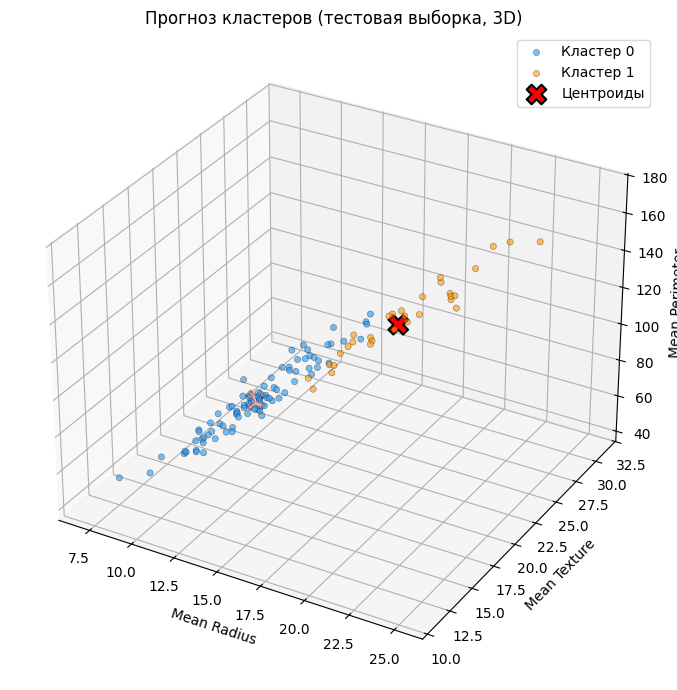

In [ ]:
test_labels = km_final.predict(X_test)

print("Прогноз кластеров для прогнозной выборки:")
for c in range(K_best_3d):
    print(f"  Кластер {c}: {np.sum(test_labels == c)} наблюдений")
print()

# 3D-визуализация прогноза
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
colors_3d = ['#2196F3', '#FF9800']

for c in range(K_best_3d):
    mask = test_labels == c
    ax.scatter(X_test.iloc[mask, 0], X_test.iloc[mask, 1], X_test.iloc[mask, 2],
               c=colors_3d[c], label=f'Кластер {c}', alpha=0.6,
               edgecolors='k', linewidth=0.3)

# Центроиды
ax.scatter(km_final.cluster_centers_[:, 0],
           km_final.cluster_centers_[:, 1],
           km_final.cluster_centers_[:, 2],
           c='red', marker='X', s = 200, edgecolors='black',
           linewidth=1.5, label='Центроиды')

ax.set_xlabel('Mean Radius')
ax.set_ylabel('Mean Texture')
ax.set_zlabel('Mean Perimeter')
ax.set_title('Прогноз кластеров (тестовая выборка, 3D)')
ax.legend()
plt.tight_layout()
plt.show()

## Дополнительное задание. Оценка точности (Accuracy)

K-means не «знает» истинные метки, поэтому нумерация кластеров может не совпадать с target.
Нужно проверить обе перестановки меток (0↔1) и выбрать ту, при которой Accuracy максимальна.

**Acc = доля совпадений между предсказанным кластером и истинным классом.**

In [10]:
def clustering_accuracy(y_true, y_pred, n_clusters):
    """
    Находит лучшее соответствие кластеров → классам перебором перестановок.
    Для K=2 это тривиально: проверяем прямое и инвертированное соответствие.
    """
    from itertools import permutations
    best_acc = 0
    best_mapping = None
    for perm in permutations(range(n_clusters)):
        # Переназначаем метки кластеров
        y_mapped = np.array([perm[label] for label in y_pred])
        acc = accuracy_score(y_true, y_mapped)
        if acc > best_acc:
            best_acc = acc
            best_mapping = perm
    return best_acc, best_mapping

# Accuracy на обучающей выборке
acc_train, map_train = clustering_accuracy(y_train, train_labels, K_best_3d)
print(f"Accuracy на обучающей выборке: {acc_train:.4f}")
print(f"  Маппинг кластеров → классам: {map_train}")

# Accuracy на прогнозной выборке
acc_test, map_test = clustering_accuracy(y_test, test_labels, K_best_3d)
print(f"\nAccuracy на прогнозной выборке: {acc_test:.4f}")
print(f"  Маппинг кластеров → классам: {map_test}")

print(f"\n{'='*50}")
print("Вывод: кластеризация K-means по 3 признакам")
print(f"достигает Accuracy ≈ {acc_test:.1%} на тестовой выборке,")
print("что говорит о хорошем соответствии найденных кластеров")
print("реальным классам (malignant / benign).")

Accuracy на обучающей выборке: 0.8593
  Маппинг кластеров → классам: (1, 0)

Accuracy на прогнозной выборке: 0.8947
  Маппинг кластеров → классам: (1, 0)

Вывод: кластеризация K-means по 3 признакам
достигает Accuracy ≈ 89.5% на тестовой выборке,
что говорит о хорошем соответствии найденных кластеров
реальным классам (malignant / benign).
